In [1]:
!pip install Pillow pydantic pydantic-settings pymupdf rapidocr-onnxruntime torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 106.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.1/972.1 kB 60.2 MB/s eta 0:00:00


In [2]:
%%writefile /content/.env
DATA_PATH=/content/data
MODEL_PATH=/content/model-output/final
HF_TOKEN=""
HF_MODEL_REPO_ID=""

FIELD_KEY_PREFIX="FIELD_KEY_"
FIELD_VALUE_PREFIX="FIELD_VALUE_"
HEADER_PREFIX="HEADER_"
ITEM_PREFIX="ITEM_"
ROW_TOLERANCE=8
EDGE_TOLERANCE=8
COLUMN_TOLERANCE=50
AMBIGUITY_K=0.1
APP_ENV=development

Writing /content/.env


# Preparacion del dataset

In [3]:
import sys
import os

# Add src folder to Python path
sys.path.append(os.path.abspath('src'))


from dataclasses import dataclass, field
from typing import List, Union
import json
from PIL import Image

# Import from your uploaded src directory
from common.common_types import LayoutElement
from common.data_storage import DataStorage

@dataclass
class PageSample:
    images: list[Image.Image]
    elements: list[LayoutElement]

paths = DataStorage.find_json_paths()
dataset: list[PageSample] = []
for path in paths:
    with open(path) as f:
        data = json.load(f)
        images = DataStorage.get_images(path.stem)
        dataset.append(PageSample(images=images, elements=data))

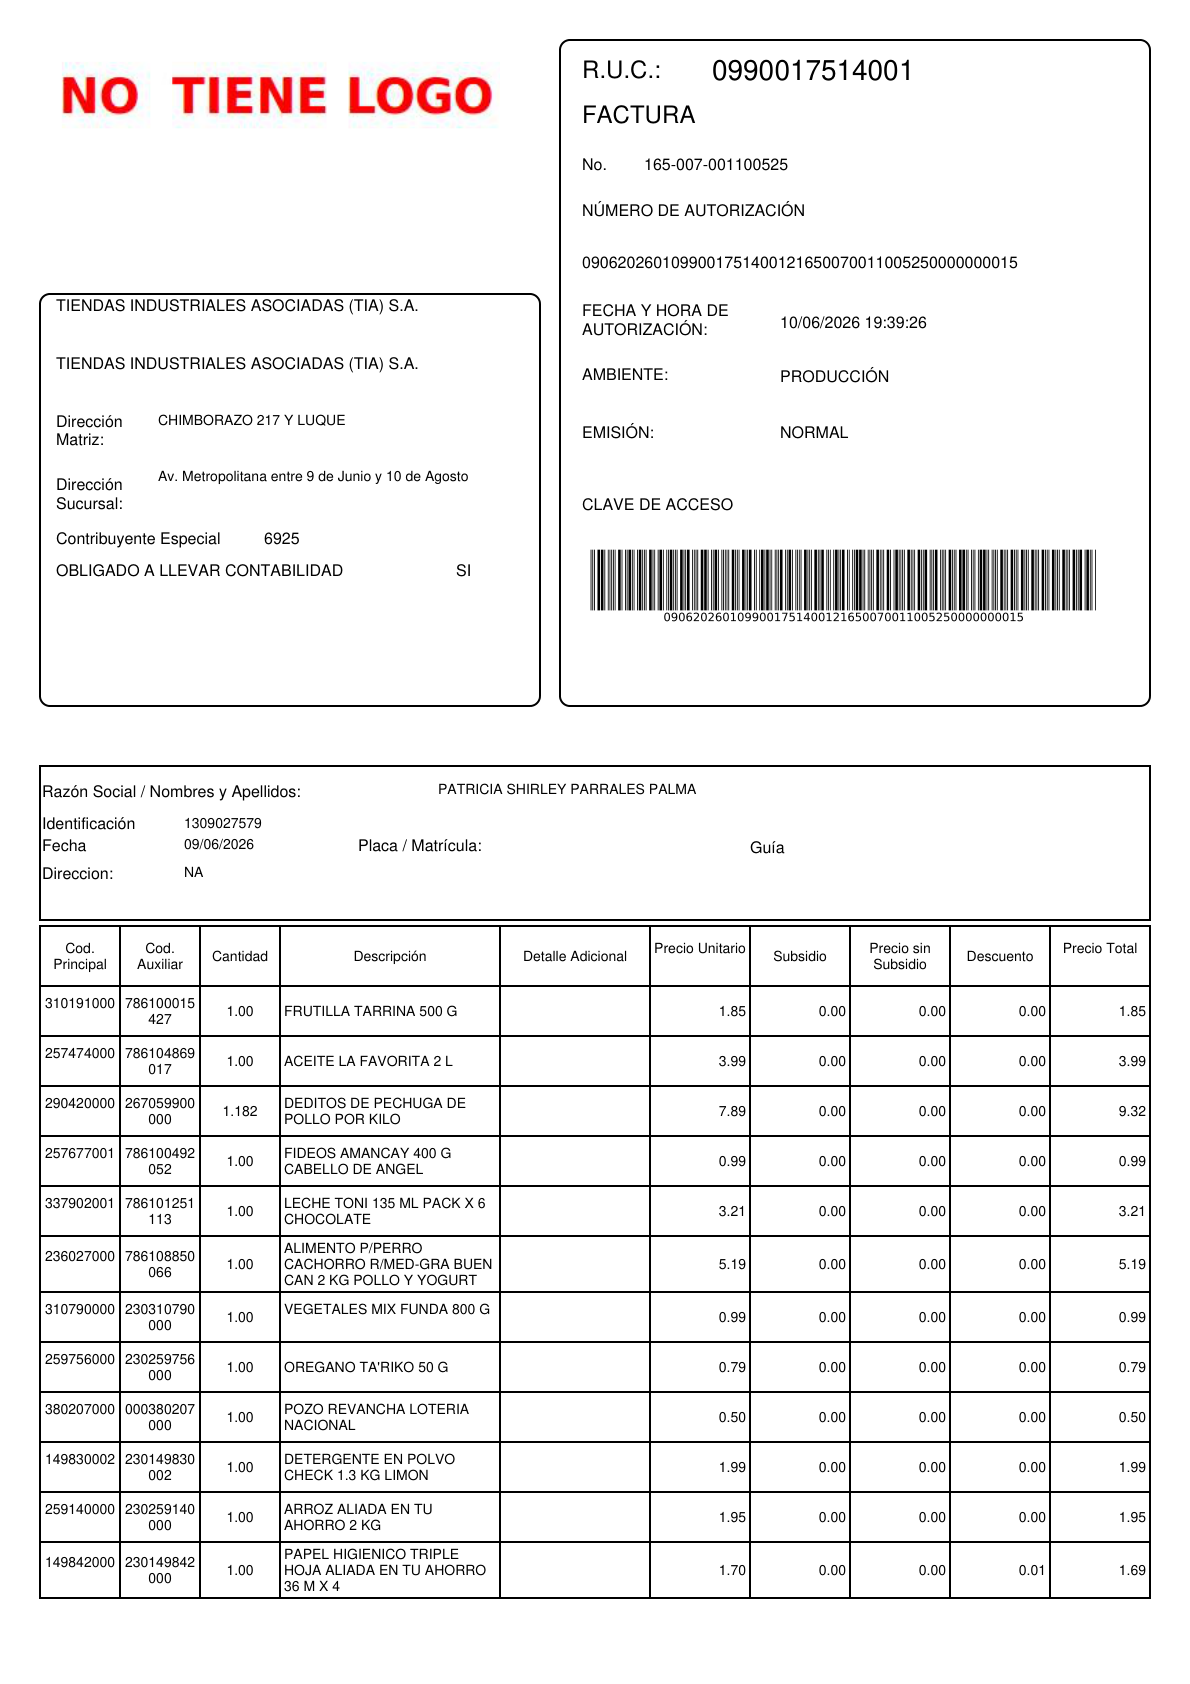

In [4]:
if dataset and dataset[0].images:
    display(dataset[0].images[0])

In [5]:
print(f"Total de PageSample: {len(dataset)}")
for id, sample in enumerate(dataset[:3], start=1):
    print(f"=== PageSample {id} ===")
    print(f"Imágenes cargadas: {len(sample.images)}")
    print(f"Cantidad de elementos: {len(sample.elements)}")
    print("Primeros elementos:", sample.elements[:2])  # Muestra solo los primeros 3 elementos para no saturar
    print("-" * 40)

Total de PageSample: 100
=== PageSample 1 ===
Imágenes cargadas: 2
Cantidad de elementos: 324
Primeros elementos: [{'label': 'FIELD_KEY_ID', 'text': 'R.U.C.:', 'source': 'digital', 'confidence': 1.0, 'page': 1, 'bbox': [291.0, 26.250022888183594, 330.33599853515625, 42.7380256652832], 'normalized_bbox': [489, 31, 555, 50]}, {'label': 'FIELD_VALUE_ID', 'text': '0990017514001', 'source': 'digital', 'confidence': 1.0, 'page': 1, 'bbox': [356.0, 24.79997444152832, 457.19195556640625, 44.03597640991211], 'normalized_bbox': [598, 29, 768, 52]}]
----------------------------------------
=== PageSample 2 ===
Imágenes cargadas: 1
Cantidad de elementos: 95
Primeros elementos: [{'label': 'FIELD_KEY_ID', 'text': 'R.U.C.:', 'source': 'digital', 'confidence': 1.0, 'page': 1, 'bbox': [291.0, 26.250022888183594, 330.33599853515625, 42.7380256652832], 'normalized_bbox': [489, 31, 555, 50]}, {'label': 'FIELD_VALUE_ID', 'text': '1791415132001', 'source': 'digital', 'confidence': 1.0, 'page': 1, 'bbox': [3

# Etiquetas

In [6]:
all_labels = set()
for doc in dataset:
    for e in doc.elements:
        all_labels.add(e["label"])

label_list = sorted(list(all_labels))
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}

print(f"Total etiquetas: {len(label_list)}")
print(f"Etiquetas: {label_list}")
print(f"ID de cada etiqueta: {id2label}")


Total etiquetas: 35
Etiquetas: ['FIELD_KEY_ADDRESS', 'FIELD_KEY_AMOUNT', 'FIELD_KEY_DATE', 'FIELD_KEY_EMAIL', 'FIELD_KEY_ID', 'FIELD_KEY_NAME', 'FIELD_KEY_TEXT', 'FIELD_VALUE_ADDRESS', 'FIELD_VALUE_AMOUNT', 'FIELD_VALUE_DATE', 'FIELD_VALUE_EMAIL', 'FIELD_VALUE_ID', 'FIELD_VALUE_NAME', 'FIELD_VALUE_TEXT', 'HEADER_PRODUCT_CODE', 'HEADER_PRODUCT_CODE_AUX', 'HEADER_PRODUCT_DETAIL', 'HEADER_PRODUCT_DISCOUNT', 'HEADER_PRODUCT_NAME', 'HEADER_PRODUCT_PRICE', 'HEADER_PRODUCT_QUANTITY', 'HEADER_PRODUCT_SUBSIDY', 'HEADER_PRODUCT_TOTAL', 'HEADER_PRODUCT_WITHOUT_SUBSIDY', 'ITEM_PRODUCT_CODE', 'ITEM_PRODUCT_CODE_AUX', 'ITEM_PRODUCT_DETAIL', 'ITEM_PRODUCT_DISCOUNT', 'ITEM_PRODUCT_NAME', 'ITEM_PRODUCT_PRICE', 'ITEM_PRODUCT_QUANTITY', 'ITEM_PRODUCT_SUBSIDY', 'ITEM_PRODUCT_TOTAL', 'ITEM_PRODUCT_WITHOUT_SUBSIDY', 'O']
ID de cada etiqueta: {0: 'FIELD_KEY_ADDRESS', 1: 'FIELD_KEY_AMOUNT', 2: 'FIELD_KEY_DATE', 3: 'FIELD_KEY_EMAIL', 4: 'FIELD_KEY_ID', 5: 'FIELD_KEY_NAME', 6: 'FIELD_KEY_TEXT', 7: 'FIELD_VALUE_

# Generacion de tensores usando el Processor  de LayoutLMv3U

Descargamos el modelo con sus pesos a traves de hugging face y para poder utilizar el procesador de LayoutMLv3 a traves de la clase `LayoutLMv3Processor`



In [ ]:
from transformers import LayoutLMv3Processor

processor = LayoutLMv3Processor.from_pretrained("microsoft/layoutlmv3-base", apply_ocr=False)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

Internamente el Processo tiene el Tokenizer y el Procesado de imagenes lo que nos permite generar los tensores adecuados.

In [ ]:
def prepare_document(elements):
    words = [e["text"] for e in elements]
    boxes = [e["normalized_bbox"] for e in elements]
    labels = [label2id[e["label"]] for e in elements]
    return words, boxes, labels

def encode_document(image:Image.Image,elements: list[LayoutElement]):
    words, boxes, labels = prepare_document(elements)

    encoding = processor(
        images=image,
        text=words,
        boxes=boxes,
        word_labels=labels,
        truncation=True,
        padding="max_length",
        max_length=512,
        return_tensors="pt"
    )
    return encoding



1. RESUMEN DE TENSORES (ENCODING DUPLE)
• input_ids      : Tipo=Tensor       | Forma=[1, 512] | Dtype=torch.int64
• attention_mask : Tipo=Tensor       | Forma=[1, 512] | Dtype=torch.int64
• bbox           : Tipo=Tensor       | Forma=[1, 512, 4] | Dtype=torch.int64
• labels         : Tipo=Tensor       | Forma=[1, 512] | Dtype=torch.int64
• pixel_values   : Tipo=Tensor       | Forma=[1, 3, 224, 224] | Dtype=torch.float32

2. MUESTRA DE TOKENIZACIÓN ALINEADA (Primeros 30 Tokens)
 Posición Token  Label ID        Etiqueta Bounding Box [x0,y0,x1,y1]  Attention Mask
        0   <s>      -100 IGNORADO (-100)               [0, 0, 0, 0]               1
        1    ĠR         4    FIELD_KEY_ID         [489, 31, 555, 50]               1
        2     .      -100 IGNORADO (-100)         [489, 31, 555, 50]               1
        3     U      -100 IGNORADO (-100)         [489, 31, 555, 50]               1
        4     .      -100 IGNORADO (-100)         [489, 31, 555, 50]               1
        5

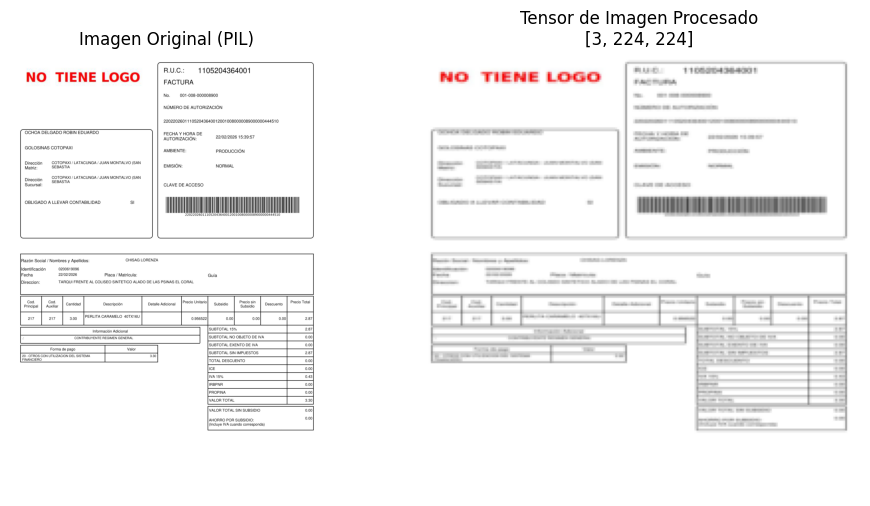

In [ ]:
import torch
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# 1. Seleccionar una página específica de prueba (por ejemplo, la primera de entrenamiento)
sample_image, sample_elements = train_data_final[0]

# 2. Generar el encoding crudo llamando a la función encode_document
encoding = encode_document(sample_image, sample_elements)

# 3. Extraer tensores individuales (descomprimiendo la dimensión batch con .squeeze(0))
input_ids = encoding["input_ids"].squeeze(0)
attention_mask = encoding["attention_mask"].squeeze(0)
bbox = encoding["bbox"].squeeze(0)
labels = encoding["labels"].squeeze(0)
pixel_values = encoding["pixel_values"].squeeze(0)

# 4. Decodificar los tokens de texto para inspección
tokens = processor.tokenizer.convert_ids_to_tokens(input_ids)

# --- IMPRESIÓN 1: ESTRUCTURA Y FORMA DE LOS TENSORES ---
print("=" * 65)
print("1. RESUMEN DE TENSORES (ENCODING DUPLE)")
print("=" * 65)
for key, tensor in encoding.items():
    print(f"• {key:<15}: Tipo={type(tensor).__name__:<12} | Forma={list(tensor.shape)} | Dtype={tensor.dtype}")

# --- IMPRESIÓN 2: TABLA DE TOKENIZACIÓN Y ESPACIALIZACIÓN ---
print("\n" + "=" * 65)
print("2. MUESTRA DE TOKENIZACIÓN ALINEADA (Primeros 30 Tokens)")
print("=" * 65)

token_data = []
for i in range(min(30, len(tokens))):
    tok = tokens[i]
    lbl_id = labels[i].item()
    lbl_str = id2label.get(lbl_id, "IGNORADO/PADDING") if lbl_id != -100 else "IGNORADO (-100)"
    box = bbox[i].tolist()
    att = attention_mask[i].item()

    token_data.append([i, tok, lbl_id, lbl_str, box, att])

df_tokens = pd.DataFrame(token_data, columns=["Posición", "Token", "Label ID", "Etiqueta", "Bounding Box [x0,y0,x1,y1]", "Attention Mask"])
print(df_tokens.to_string(index=False))

# --- IMPRESIÓN 3: TENSORES DE IMAGEN Y VISUALIZACIÓN ---
print("\n" + "=" * 65)
print("3. INSPECCIÓN Y PREVISUALIZACIÓN DEL TENSOR DE IMAGEN")
print("=" * 65)
print(f"Tensor de Imagen (pixel_values): {pixel_values.shape} (Canales, Alto, Ancho)")
print(f"Rango de valores de píxel (normalizados): Mín={pixel_values.min():.2f}, Máx={pixel_values.max():.2f}")

# Reconstruir el tensor de la imagen normalizada para visualizarlo
# (Des-normalizar cambiando la forma [C, H, W] -> [H, W, C])
img_tensor_vis = pixel_values.permute(1, 2, 0).cpu().numpy()
# Normalizar al rango 0-1 para renderizado correcto en matplotlib
img_tensor_vis = (img_tensor_vis - img_tensor_vis.min()) / (img_tensor_vis.max() - img_tensor_vis.min())

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(sample_image)
axes[0].set_title("Imagen Original (PIL)")
axes[0].axis("off")

axes[1].imshow(img_tensor_vis)
axes[1].set_title(f"Tensor de Imagen Procesado\n{list(pixel_values.shape)}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Validacion de los parches de imagenes

1. INFORMACIÓN DE VISUAL PATCHES EN LAYOUTLMV3
• Dimensión de la imagen normalizada: 224 x 224 píxeles
• Tamaño de cada parche (patch_size): 16 x 16 píxeles
• Matriz de parches: 14 x 14
• Total de parches visuales generados: 196 parches


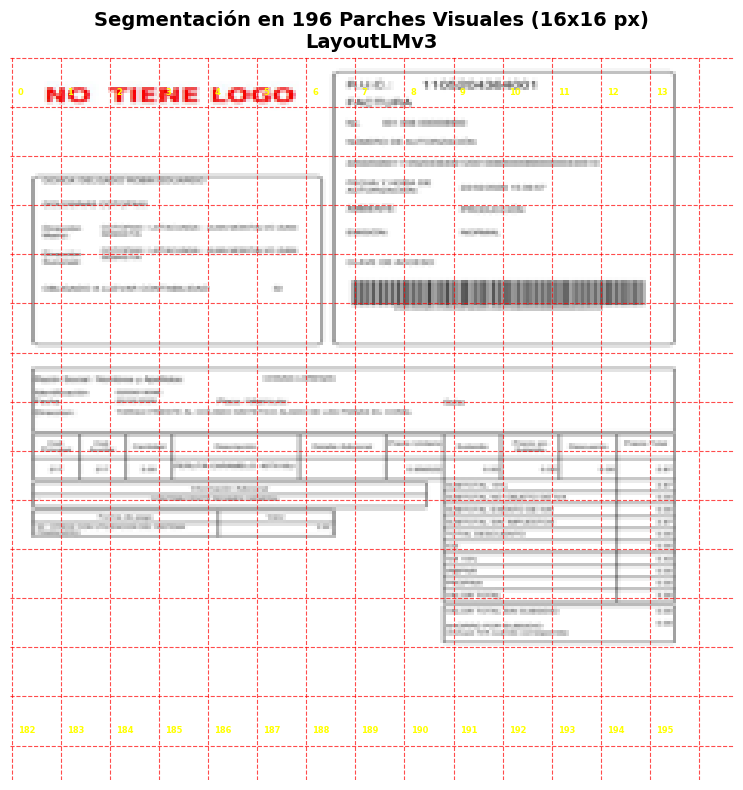

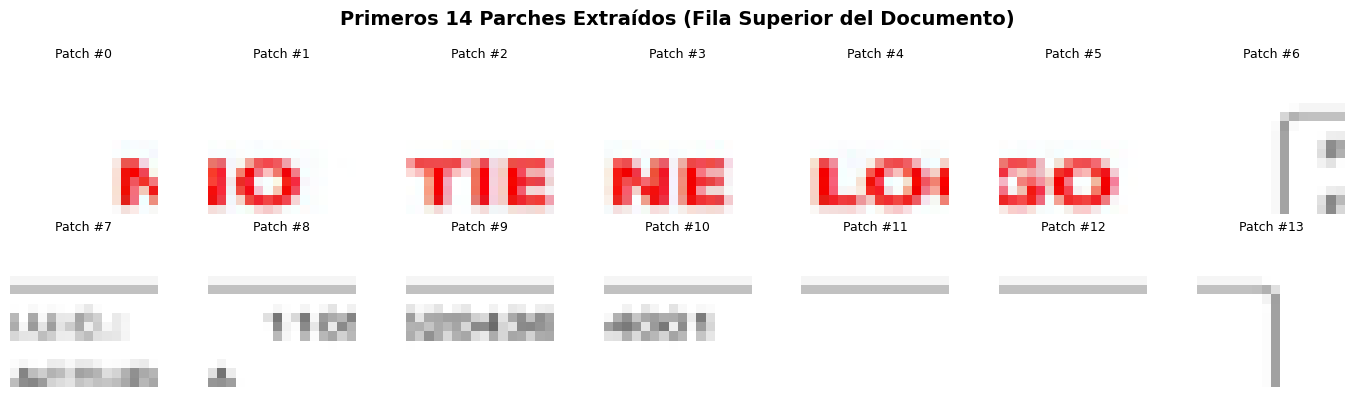

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Seleccionar un documento de prueba (por ejemplo, el primero)
sample_image, sample_elements = train_data_final[0]

# 2. Configurar dimensiones de LayoutLMv3
IMAGE_SIZE = (224, 224)
PATCH_SIZE = 16  # Tamaño estándar del parche en parches de visión ViT / LayoutLMv3

# Redimensionar la imagen como lo hace el LayoutLMv3Processor
img_resized = sample_image.resize(IMAGE_SIZE)
img_np = np.array(img_resized)

# 3. Calcular parches
num_patches_per_dim = IMAGE_SIZE[0] // PATCH_SIZE  # 224 / 16 = 14 parches por fila/columna
total_patches = num_patches_per_dim * num_patches_per_dim  # 14 x 14 = 196 visual patches

print("=" * 65)
print("1. INFORMACIÓN DE VISUAL PATCHES EN LAYOUTLMV3")
print("=" * 65)
print(f"• Dimensión de la imagen normalizada: {IMAGE_SIZE[0]} x {IMAGE_SIZE[1]} píxeles")
print(f"• Tamaño de cada parche (patch_size): {PATCH_SIZE} x {PATCH_SIZE} píxeles")
print(f"• Matriz de parches: {num_patches_per_dim} x {num_patches_per_dim}")
print(f"• Total de parches visuales generados: {total_patches} parches")

# --- GRAFICAR LA CUADRÍCULA DE PARCHES SOBRE LA IMAGEN ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_np)

# Dibujar las líneas divisorias de la retícula de parches
for i in range(0, IMAGE_SIZE[0] + 1, PATCH_SIZE):
    ax.axhline(i, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.axvline(i, color="red", linestyle="--", linewidth=0.8, alpha=0.7)

# Numerar los primeros parches para entender la secuencia de ingesta
patch_idx = 0
for row in range(num_patches_per_dim):
    for col in range(num_patches_per_dim):
        x = col * PATCH_SIZE + 2
        y = row * PATCH_SIZE + 12
        # Numerar los primeros parches y los últimos
        if patch_idx < 14 or patch_idx >= total_patches - 14:
            ax.text(x, y, str(patch_idx), color="yellow", fontsize=6, fontweight="bold")
        patch_idx += 1

ax.set_title(f"Segmentación en {total_patches} Parches Visuales (16x16 px)\nLayoutLMv3", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

# --- MOSTRAR UNA MUESTRA DE PARCHES EXTRAÍDOS INDIVIDUALMENTE ---
fig, axes = plt.subplots(2, 7, figsize=(14, 4))
fig.suptitle("Primeros 14 Parches Extraídos (Fila Superior del Documento)", fontsize=14, fontweight="bold")

patch_count = 0
for col in range(num_patches_per_dim):
    # Recortar el parche específico
    y_start, y_end = 0 * PATCH_SIZE, (0 + 1) * PATCH_SIZE
    x_start, x_end = col * PATCH_SIZE, (col + 1) * PATCH_SIZE
    patch_crop = img_np[y_start:y_end, x_start:x_end]

    ax = axes[patch_count // 7, patch_count % 7]
    ax.imshow(patch_crop)
    ax.set_title(f"Patch #{patch_count}", fontsize=9)
    ax.axis("off")
    patch_count += 1

plt.tight_layout()
plt.show()

# Fine tunning de LayoutMLv3

## Creacion del dataset personalizado

Con el fin de realizar el fine-tuning, se deben empaquetar los datos en una clase denominada TorchDataset, que es compatible con Pytorch. El TorchDataset funciona como una capa intermedia estandarizada entre los datos preprocesados y el Trainer de Hugging Face

In [ ]:
from torch.utils.data import Dataset as TorchDataset

def extract_per_page(page:PageSample):
    separated = []
    for index,image in enumerate(page.images):
        current_page = index + 1
        current_elements = [e for e in page.elements if e["page"] == current_page]
        separated.append((image, current_elements))
    return separated

class InvoiceDataset(TorchDataset):
    def __init__(self, documents):
        self.documents = documents

    def __getitem__(self, idx):
        image, elements = self.documents[idx]
        encoding = encode_document(image, elements)
        return {k: v.squeeze(0) for k, v in encoding.items()}

    def __len__(self):
        return len(self.documents)

split = int(len(dataset) * 0.8)

train_data = dataset[:split]
eval_data = dataset[split:]

train_data_final = []
for page in train_data:
    train_data_final.extend(extract_per_page(page))

eval_data_final = []
for page in eval_data:
    eval_data_final.extend(extract_per_page(page))


train_dataset = InvoiceDataset(train_data_final)
val_dataset = InvoiceDataset(eval_data_final)

print()
print(f"Train: {len(train_data)} | Val: {len(eval_data)}")
print(f"Train pages: {len(train_data_final)} | Val pages: {len(eval_data_final)}")


Train: 80 | Val: 20
Train pages: 115 | Val pages: 27


## Carga del modelo preentrenado y asignacion de la capa de clasificacion

Se usan las 35 capas ya definidas como capas de salida para el modelo.

In [ ]:
from transformers import LayoutLMv3ForTokenClassification, TrainingArguments, Trainer
import torch

model = LayoutLMv3ForTokenClassification.from_pretrained(
    "microsoft/layoutlmv3-base",
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                        | Status  | 
---------------------------+---------+-
classifier.dense.bias      | MISSING | 
classifier.out_proj.bias   | MISSING | 
classifier.out_proj.weight | MISSING | 
classifier.dense.weight    | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Se definen las metricas de evalucion ponderada y se establecen los hiperparametros de entrenamiento del modelo.

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from transformers import LayoutLMv3Processor


def preprocess_logits_for_metrics(logits, labels):
    if isinstance(logits, tuple):
        logits = logits[0]
    return logits.argmax(dim=-1)

def compute_metrics(p):
    predictions, labels = p

    true_predictions = [
        id2label[pred_id]
        for pred, lab in zip(predictions, labels)
        for (pred_id, l) in zip(pred, lab) if l != -100
    ]
    true_labels = [
        id2label[l]
        for pred, lab in zip(predictions, labels)
        for (pred_id, l) in zip(pred, lab) if l != -100
    ]

    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, true_predictions, average="weighted", zero_division=0
    )
    acc = accuracy_score(true_labels, true_predictions)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": acc,
    }
training_args = TrainingArguments(
    output_dir="./model-output",
    num_train_epochs=10,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    learning_rate=5e-5,
    save_steps=50,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    eval_accumulation_steps=1
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    preprocess_logits_for_metrics=preprocess_logits_for_metrics,

)

trainer.train()

trainer.save_model("./model-output/final")
processor.save_pretrained("./model-output/final")

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.616923,0.234097,0.992072,0.992926,0.992169,0.992926
2,0.098732,0.049208,0.994474,0.995452,0.994959,0.995452
3,0.044127,0.032750,0.995037,0.995958,0.995448,0.995958
4,0.018383,0.025339,0.996475,0.997473,0.996972,0.997473
5,0.013223,0.028382,0.996018,0.996968,0.996468,0.996968
6,0.010109,0.022105,0.996475,0.997473,0.996972,0.997473
7,0.007980,0.020483,0.996979,0.997979,0.997476,0.997979
8,0.006760,0.020197,0.996979,0.997979,0.997476,0.997979
9,0.007126,0.020047,0.996979,0.997979,0.997476,0.997979
10,0.006237,0.019999,0.996979,0.997979,0.997476,0.997979


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['./model-output/final/processor_config.json']

# Graficas de la evaluacion del modelo para el set de validacion.

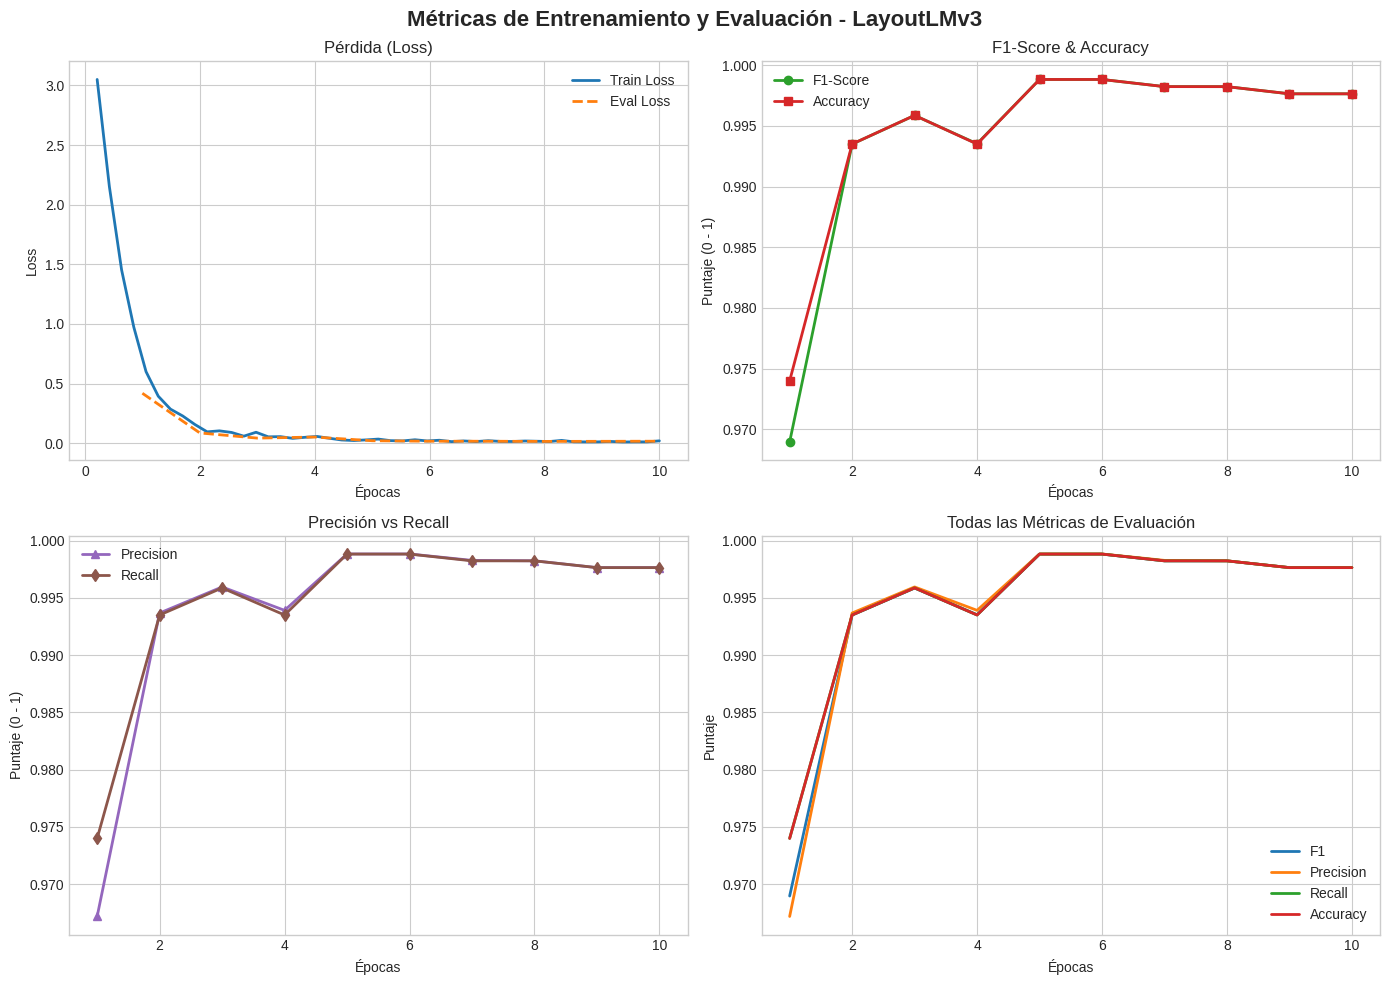

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extraer el historial de registros del Trainer
logs = trainer.state.log_history

# 2. Procesar los registros en estructuras de datos claras
train_logs = []
eval_logs = []

for log in logs:
    if "loss" in log and "epoch" in log:
        train_logs.append({"epoch": log["epoch"], "train_loss": log["loss"]})
    if "eval_loss" in log and "epoch" in log:
        eval_logs.append({
            "epoch": log["epoch"],
            "eval_loss": log["eval_loss"],
            "precision": log.get("eval_precision", 0),
            "recall": log.get("eval_recall", 0),
            "f1": log.get("eval_f1", 0),
            "accuracy": log.get("eval_accuracy", 0)
        })

# Convertir a DataFrames de Pandas
df_train = pd.DataFrame(train_logs)
df_eval = pd.DataFrame(eval_logs)

# 3. Configurar y generar las gráficas
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Métricas de Entrenamiento y Evaluación - LayoutLMv3", fontsize=16, fontweight="bold")

# Gráfica 1: Pérdida (Loss)
axes[0, 0].plot(df_train["epoch"], df_train["train_loss"], label="Train Loss", color="#1f77b4", linewidth=2)
axes[0, 0].plot(df_eval["epoch"], df_eval["eval_loss"], label="Eval Loss", color="#ff7f0e", linewidth=2, linestyle="--")
axes[0, 0].set_title("Pérdida (Loss)")
axes[0, 0].set_xlabel("Épocas")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

# Gráfica 2: F1-Score y Accuracy
axes[0, 1].plot(df_eval["epoch"], df_eval["f1"], label="F1-Score", color="#2ca02c", linewidth=2, marker="o")
axes[0, 1].plot(df_eval["epoch"], df_eval["accuracy"], label="Accuracy", color="#d62728", linewidth=2, marker="s")
axes[0, 1].set_title("F1-Score & Accuracy")
axes[0, 1].set_xlabel("Épocas")
axes[0, 1].set_ylabel("Puntaje (0 - 1)")
axes[0, 1].legend()

# Gráfica 3: Precisión y Recall
axes[1, 0].plot(df_eval["epoch"], df_eval["precision"], label="Precision", color="#9467bd", linewidth=2, marker="^")
axes[1, 0].plot(df_eval["epoch"], df_eval["recall"], label="Recall", color="#8c564b", linewidth=2, marker="d")
axes[1, 0].set_title("Precisión vs Recall")
axes[1, 0].set_xlabel("Épocas")
axes[1, 0].set_ylabel("Puntaje (0 - 1)")
axes[1, 0].legend()

# Gráfica 4: Resumen de todas las métricas de evaluación
axes[1, 1].plot(df_eval["epoch"], df_eval["f1"], label="F1", linewidth=2)
axes[1, 1].plot(df_eval["epoch"], df_eval["precision"], label="Precision", linewidth=2)
axes[1, 1].plot(df_eval["epoch"], df_eval["recall"], label="Recall", linewidth=2)
axes[1, 1].plot(df_eval["epoch"], df_eval["accuracy"], label="Accuracy", linewidth=2)
axes[1, 1].set_title("Todas las Métricas de Evaluación")
axes[1, 1].set_xlabel("Épocas")
axes[1, 1].set_ylabel("Puntaje")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("./model-output/metricas_entrenamiento.png", dpi=300)
plt.show()

# Arquitectura final del modelo con fine tunning completo.

In [ ]:
import torch
from torchinfo import summary

# 1. Detectar automáticamente si el modelo está en GPU o CPU
device = next(model.parameters()).device

# 2. Crear los tensores dummy y enviarlos AL MISMO dispositivo
dummy_input = {
    "input_ids": torch.zeros((1, 512), dtype=torch.long, device=device),
    "attention_mask": torch.ones((1, 512), dtype=torch.long, device=device),
    "bbox": torch.zeros((1, 512, 4), dtype=torch.long, device=device),
    "pixel_values": torch.zeros((1, 3, 224, 224), dtype=torch.float32, device=device),
}

# 3. Generar el resumen
summary(model, input_data=dummy_input, depth=3)

Layer (type:depth-idx)                                       Output Shape              Param #
LayoutLMv3ForTokenClassification                             [1, 512, 35]              --
├─LayoutLMv3Model: 1-1                                       [1, 709, 768]             152,064
│    └─LayoutLMv3TextEmbeddings: 2-1                         [1, 512, 768]             39,524,864
│    └─LayoutLMv3PatchEmbeddings: 2-2                        [1, 196, 768]             590,592
│    └─Dropout: 2-3                                          [1, 197, 768]             --
│    └─LayerNorm: 2-4                                        [1, 197, 768]             1,536
│    └─LayerNorm: 2-5                                        [1, 709, 768]             1,536
│    └─Dropout: 2-6                                          [1, 709, 768]             --
│    └─LayoutLMv3Encoder: 2-7                                [1, 709, 768]             85,056,384
├─Dropout: 1-2                                               [1

# Test de Congelamiento de las capas del modelo base

In [ ]:
model_freeze = LayoutLMv3ForTokenClassification.from_pretrained(
    "microsoft/layoutlmv3-base",
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                        | Status  | 
---------------------------+---------+-
classifier.out_proj.bias   | MISSING | 
classifier.dense.weight    | MISSING | 
classifier.out_proj.weight | MISSING | 
classifier.dense.bias      | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import torch

# 1. Congelar TODOS los parámetros del modelo base (LayoutLMv3Model)
for param in model_freeze.layoutlmv3.parameters():
    param.requires_grad = False

# 2. Asegurar que la cabeza de clasificación (classifier) permanezca ENTRENABLE
for param in model_freeze.classifier.parameters():
    param.requires_grad = True

# 3. Verificación de parámetros entrenables vs congelados
trainable_params = sum(p.numel() for p in model_freeze.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_freeze.parameters())
frozen_params = total_params - trainable_params

print("=" * 60)
print("ESTADO DE PARÁMETROS TRAS EL CONGELAMIENTO")
print("=" * 60)
print(f"• Parámetros Totales:      {total_params:,}")
print(f"• Parámetros Congelados:   {frozen_params:,} ({frozen_params/total_params*100:.2f}%)")
print(f"• Parámetros Entrenables:  {trainable_params:,} ({trainable_params/total_params*100:.2f}%)")



ESTADO DE PARÁMETROS TRAS EL CONGELAMIENTO
• Parámetros Totales:      125,944,483
• Parámetros Congelados:   125,326,976 (99.51%)
• Parámetros Entrenables:  617,507 (0.49%)


In [ ]:
training_args = TrainingArguments(
    output_dir="./layoutlmv3-frozen-output",
    num_train_epochs=15,                    # Se incrementa ligeramente ya que entrena rápido
    per_device_train_batch_size=4,          # Aumentado a 4 aprovechando la reducción de VRAM
    per_device_eval_batch_size=4,
    learning_rate=1e-3,                     # LR más alto (1e-3) adecuado para entrenar solo la cabeza lineal
    weight_decay=0.01,                      # Regularización L2 sobre la capa de clasificación
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",             # Carga el mejor modelo basado en el F1-Score
    greater_is_better=True,
    eval_accumulation_steps=1,
    report_to="none"
)

trainer = Trainer(
    model=model_freeze,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    preprocess_logits_for_metrics=preprocess_logits_for_metrics,
)

# Iniciar el entrenamiento
print("Iniciando entrenamiento con el backbone congelado...")
trainer.train()

# Guardar el modelo y el preprocesador final
trainer.save_model("./layoutlmv3-frozen-best")
processor.save_pretrained("./layoutlmv3-frozen-best")
print("\n¡Entrenamiento finalizado y modelo guardado en './layoutlmv3-frozen-best'!")

Iniciando entrenamiento con el backbone congelado...


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,1.014524,0.414172,0.924690,0.916667,0.915295,0.916667
2,0.301884,0.180355,0.965006,0.962766,0.962939,0.962766
3,0.157864,0.117367,0.978287,0.976950,0.977039,0.976950
4,0.109314,0.086114,0.981152,0.980496,0.980578,0.980496
5,0.084423,0.072898,0.984007,0.983452,0.983534,0.983452
6,0.073419,0.064272,0.986130,0.985816,0.985808,0.985816
7,0.059718,0.058822,0.988367,0.988180,0.988176,0.988180
8,0.058555,0.058806,0.987333,0.986998,0.986995,0.986998
9,0.042603,0.055125,0.988631,0.988180,0.988119,0.988180
10,0.041175,0.048895,0.989677,0.989362,0.989387,0.989362


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


¡Entrenamiento finalizado y modelo guardado en './layoutlmv3-frozen-best'!


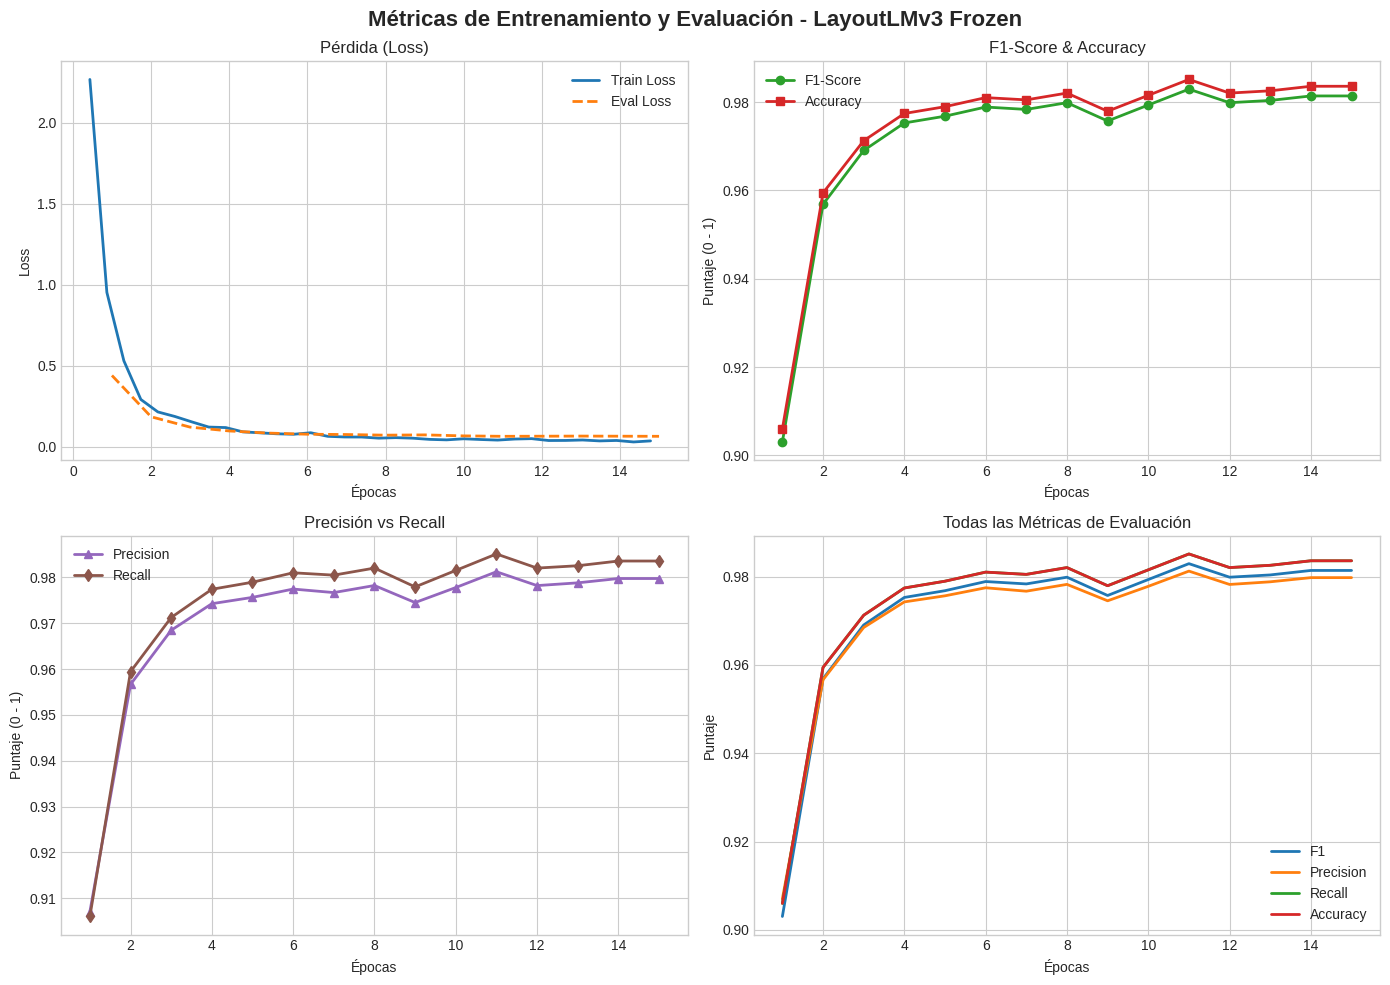

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extraer el historial de registros del Trainer
logs = trainer.state.log_history

# 2. Procesar los registros en estructuras de datos claras
train_logs = []
eval_logs = []

for log in logs:
    if "loss" in log and "epoch" in log:
        train_logs.append({"epoch": log["epoch"], "train_loss": log["loss"]})
    if "eval_loss" in log and "epoch" in log:
        eval_logs.append({
            "epoch": log["epoch"],
            "eval_loss": log["eval_loss"],
            "precision": log.get("eval_precision", 0),
            "recall": log.get("eval_recall", 0),
            "f1": log.get("eval_f1", 0),
            "accuracy": log.get("eval_accuracy", 0)
        })

# Convertir a DataFrames de Pandas
df_train = pd.DataFrame(train_logs)
df_eval = pd.DataFrame(eval_logs)

# 3. Configurar y generar las gráficas
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Métricas de Entrenamiento y Evaluación - LayoutLMv3 Frozen", fontsize=16, fontweight="bold")

# Gráfica 1: Pérdida (Loss)
axes[0, 0].plot(df_train["epoch"], df_train["train_loss"], label="Train Loss", color="#1f77b4", linewidth=2)
axes[0, 0].plot(df_eval["epoch"], df_eval["eval_loss"], label="Eval Loss", color="#ff7f0e", linewidth=2, linestyle="--")
axes[0, 0].set_title("Pérdida (Loss)")
axes[0, 0].set_xlabel("Épocas")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

# Gráfica 2: F1-Score y Accuracy
axes[0, 1].plot(df_eval["epoch"], df_eval["f1"], label="F1-Score", color="#2ca02c", linewidth=2, marker="o")
axes[0, 1].plot(df_eval["epoch"], df_eval["accuracy"], label="Accuracy", color="#d62728", linewidth=2, marker="s")
axes[0, 1].set_title("F1-Score & Accuracy")
axes[0, 1].set_xlabel("Épocas")
axes[0, 1].set_ylabel("Puntaje (0 - 1)")
axes[0, 1].legend()

# Gráfica 3: Precisión y Recall
axes[1, 0].plot(df_eval["epoch"], df_eval["precision"], label="Precision", color="#9467bd", linewidth=2, marker="^")
axes[1, 0].plot(df_eval["epoch"], df_eval["recall"], label="Recall", color="#8c564b", linewidth=2, marker="d")
axes[1, 0].set_title("Precisión vs Recall")
axes[1, 0].set_xlabel("Épocas")
axes[1, 0].set_ylabel("Puntaje (0 - 1)")
axes[1, 0].legend()

# Gráfica 4: Resumen de todas las métricas de evaluación
axes[1, 1].plot(df_eval["epoch"], df_eval["f1"], label="F1", linewidth=2)
axes[1, 1].plot(df_eval["epoch"], df_eval["precision"], label="Precision", linewidth=2)
axes[1, 1].plot(df_eval["epoch"], df_eval["recall"], label="Recall", linewidth=2)
axes[1, 1].plot(df_eval["epoch"], df_eval["accuracy"], label="Accuracy", linewidth=2)
axes[1, 1].set_title("Todas las Métricas de Evaluación")
axes[1, 1].set_xlabel("Épocas")
axes[1, 1].set_ylabel("Puntaje")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("./layoutlmv3-frozen-output/metricas_entrenamiento.png", dpi=300)
plt.show()